Setup and Library Check

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
except Exception as error:
    print("PyTorch check failed:", error)

os.makedirs("results", exist_ok=True)
print("Results folder ready.")

PyTorch version: 2.11.0+cpu
CUDA available: False
Results folder ready.


Preview Easy, Medium, and Hard Maps

In [16]:
from maze_env import MazeEnv

for difficulty in ["easy", "medium", "hard"]:
    env = MazeEnv(difficulty=difficulty)
    env.reset()
    env.render()

Difficulty: easy
Size: 6x6
Obstacle density: 0.2
Max steps: 100

A . . # . . 
. # . . . # 
. # . . . . 
# . # . # . 
. . # . . . 
. . # # . G 

Difficulty: medium
Size: 8x8
Obstacle density: 0.25
Max steps: 150

A . # # . . . . 
. . . . . . . # 
# . # . . # . # 
. . # . . # . # 
. . . # . . . # 
. . . # . . . . 
. # # . . . . . 
. . . # # # . G 

Difficulty: hard
Size: 10x10
Obstacle density: 0.3
Max steps: 200

A . . # . . . # . # 
. . . . # . # . . # 
. . # . . . . # . # 
. . . . # . . # . # 
. . # . . # . . # . 
. # . . . . . # # . 
. # # # . # . . # # 
. # # . . . . . # # 
. . . . . . # . . . 
# # . . # # . . . G 



Train Q-learning on All Maps

In [17]:
from train_q_learning import train_q_learning, save_q_learning_results, summarize_results

q_learning_summaries = []

for difficulty in ["easy", "medium", "hard"]:
    print(f"\nTraining Q-learning on {difficulty.upper()} map...")
    results, agent = train_q_learning(difficulty=difficulty, episodes=500)
    save_q_learning_results(results)
    q_learning_summaries.append(summarize_results(results))

q_learning_df = pd.DataFrame(q_learning_summaries)
q_learning_df.to_csv("results/q_learning_summary.csv", index=False)
q_learning_df


Training Q-learning on EASY map...
[EASY] Episode: 50, Reward: -127, Steps: 66, Success: 1, Epsilon: 0.778
[EASY] Episode: 100, Reward: 71, Steps: 21, Success: 1, Epsilon: 0.606
[EASY] Episode: 150, Reward: 59, Steps: 15, Success: 1, Epsilon: 0.471
[EASY] Episode: 200, Reward: 59, Steps: 15, Success: 1, Epsilon: 0.367
[EASY] Episode: 250, Reward: 55, Steps: 28, Success: 1, Epsilon: 0.286
[EASY] Episode: 300, Reward: 69, Steps: 14, Success: 1, Epsilon: 0.222
[EASY] Episode: 350, Reward: 79, Steps: 13, Success: 1, Epsilon: 0.173
[EASY] Episode: 400, Reward: 91, Steps: 10, Success: 1, Epsilon: 0.135
[EASY] Episode: 450, Reward: 91, Steps: 10, Success: 1, Epsilon: 0.105
[EASY] Episode: 500, Reward: 91, Steps: 10, Success: 1, Epsilon: 0.082
Saved results for Q-learning on easy map.

Training Q-learning on MEDIUM map...
[MEDIUM] Episode: 50, Reward: -529, Steps: 150, Success: 0, Epsilon: 0.778
[MEDIUM] Episode: 100, Reward: -33, Steps: 53, Success: 1, Epsilon: 0.606
[MEDIUM] Episode: 150, R

,difficulty,algorithm,success_rate_last_100,avg_steps_success_last_100,avg_reward_last_100,avg_invalid_moves_last_100,training_time_seconds
0,easy,Q-learning,100.0,11.12,86.28,0.40,0.083775
1,medium,Q-learning,100.0,15.65,80.76,0.51,0.115723
2,hard,Q-learning,100.0,20.06,75.90,0.56,0.356560


Train DQN on All Maps

In [18]:
from train_dqn import train_dqn, save_dqn_results, summarize_results

dqn_summaries = []

for difficulty in ["easy", "medium", "hard"]:
    print(f"\nTraining DQN on {difficulty.upper()} map...")
    results, agent = train_dqn(difficulty=difficulty, episodes=500)
    save_dqn_results(results)
    dqn_summaries.append(summarize_results(results))

dqn_df = pd.DataFrame(dqn_summaries)
dqn_df.to_csv("results/dqn_summary.csv", index=False)
dqn_df


Training DQN on EASY map...
[EASY] Episode: 50, Reward: -452, Steps: 100, Success: 0, Epsilon: 0.778, Loss: 0.3495
[EASY] Episode: 100, Reward: 25, Steps: 22, Success: 1, Epsilon: 0.606, Loss: 0.4152
[EASY] Episode: 150, Reward: 57, Steps: 17, Success: 1, Epsilon: 0.471, Loss: 3.2641
[EASY] Episode: 200, Reward: 91, Steps: 10, Success: 1, Epsilon: 0.367, Loss: 0.9409
[EASY] Episode: 250, Reward: 69, Steps: 14, Success: 1, Epsilon: 0.286, Loss: 2.4079
[EASY] Episode: 300, Reward: 79, Steps: 13, Success: 1, Epsilon: 0.222, Loss: 0.1278
[EASY] Episode: 350, Reward: 91, Steps: 10, Success: 1, Epsilon: 0.173, Loss: 0.2432
[EASY] Episode: 400, Reward: 91, Steps: 10, Success: 1, Epsilon: 0.135, Loss: 0.0028
[EASY] Episode: 450, Reward: 91, Steps: 10, Success: 1, Epsilon: 0.105, Loss: 0.2027
[EASY] Episode: 500, Reward: 79, Steps: 13, Success: 1, Epsilon: 0.082, Loss: 0.3375
Saved results for DQN on easy map.

Training DQN on MEDIUM map...
[MEDIUM] Episode: 50, Reward: -59, Steps: 43, Success

,difficulty,algorithm,success_rate_last_100,avg_steps_success_last_100,avg_reward_last_100,avg_invalid_moves_last_100,training_time_seconds
0,easy,DQN,100.0,11.49,85.28,0.47,32.911779
1,medium,DQN,100.0,15.46,82.12,0.38,66.131809
2,hard,DQN,100.0,19.98,75.62,0.60,130.337847


Final Comparison Table

In [19]:
q_learning_df = pd.read_csv("results/q_learning_summary.csv")
dqn_df = pd.read_csv("results/dqn_summary.csv")

comparison_df = pd.concat([q_learning_df, dqn_df], ignore_index=True)
comparison_df.to_csv("results/final_comparison.csv", index=False)

comparison_df

,difficulty,algorithm,success_rate_last_100,avg_steps_success_last_100,avg_reward_last_100,avg_invalid_moves_last_100,training_time_seconds
0,easy,Q-learning,100.0,11.12,86.28,0.40,0.083775
1,medium,Q-learning,100.0,15.65,80.76,0.51,0.115723
2,hard,Q-learning,100.0,20.06,75.90,0.56,0.356560
3,easy,DQN,100.0,11.49,85.28,0.47,32.911779
4,medium,DQN,100.0,15.46,82.12,0.38,66.131809
5,hard,DQN,100.0,19.98,75.62,0.60,130.337847


Comparison Graphs

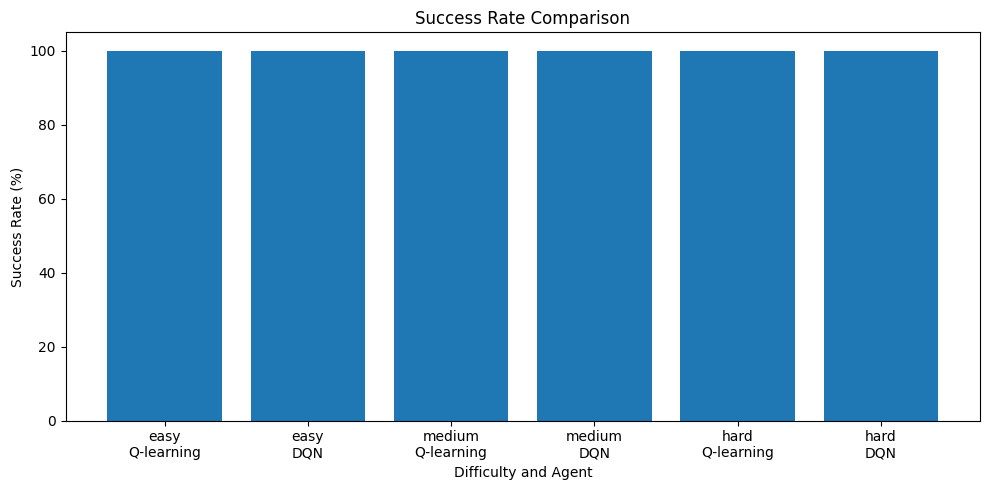

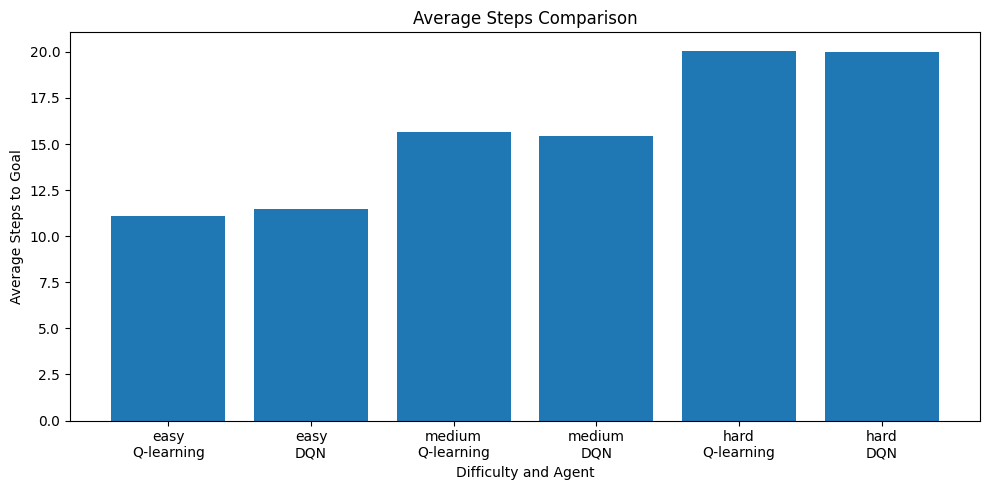

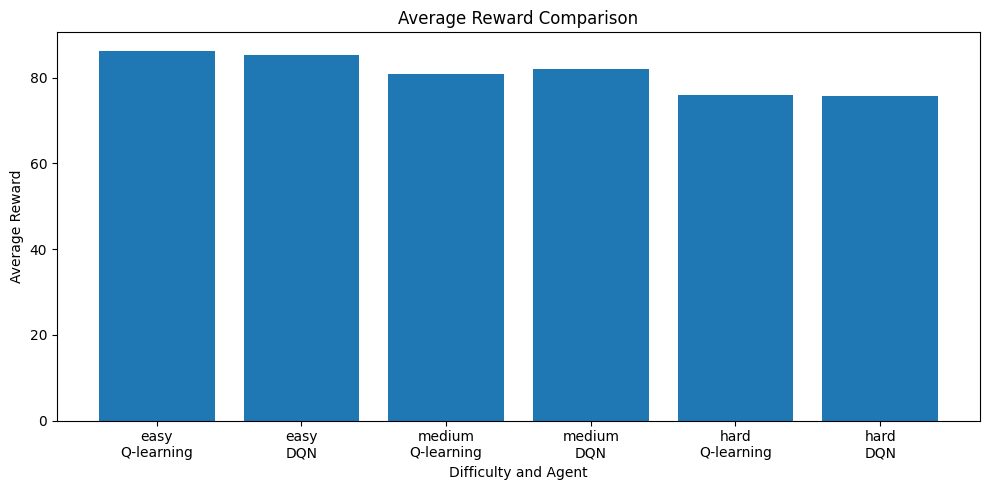

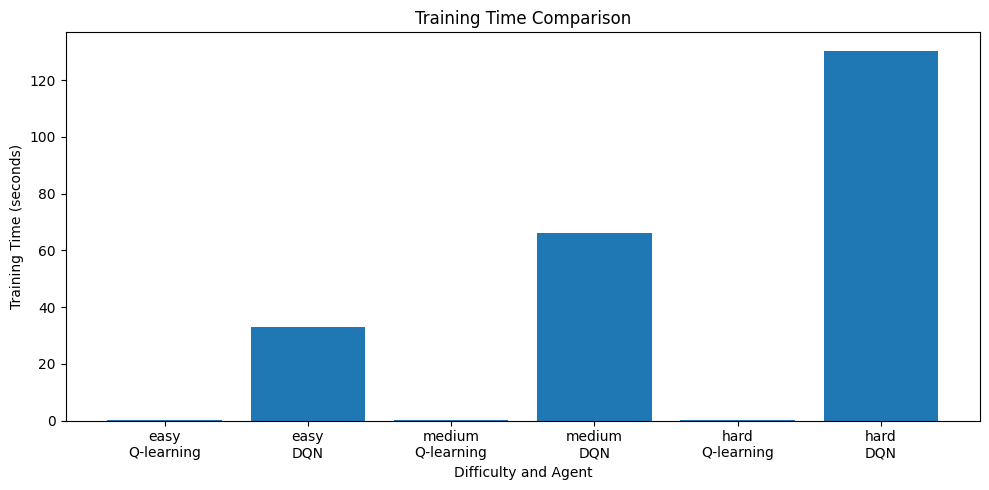

In [20]:
def plot_comparison(metric, ylabel, title):
    difficulties = ["easy", "medium", "hard"]
    algorithms = ["Q-learning", "DQN"]

    labels = []
    values = []

    for difficulty in difficulties:
        for algorithm in algorithms:
            row = comparison_df[
                (comparison_df["difficulty"] == difficulty) &
                (comparison_df["algorithm"] == algorithm)
            ]
            if not row.empty:
                labels.append(f"{difficulty}\n{algorithm}")
                values.append(row.iloc[0][metric])

    plt.figure(figsize=(10, 5))
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel("Difficulty and Agent")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

plot_comparison("success_rate_last_100", "Success Rate (%)", "Success Rate Comparison")
plot_comparison("avg_steps_success_last_100", "Average Steps to Goal", "Average Steps Comparison")
plot_comparison("avg_reward_last_100", "Average Reward", "Average Reward Comparison")
plot_comparison("training_time_seconds", "Training Time (seconds)", "Training Time Comparison")

Display Saved Training Graphs

Q-learning_easy_rewards.png


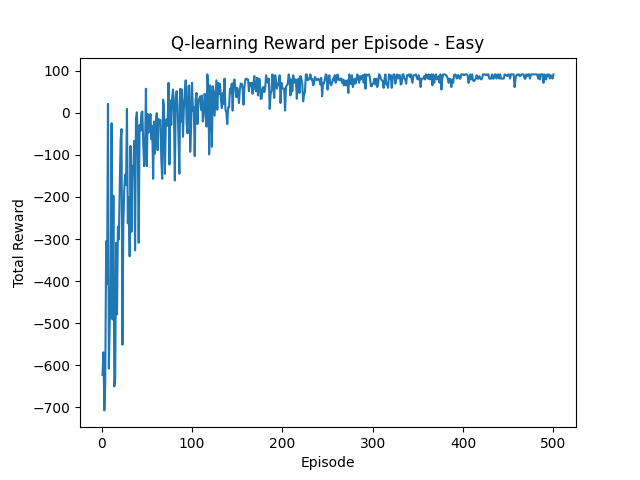

Q-learning_medium_rewards.png


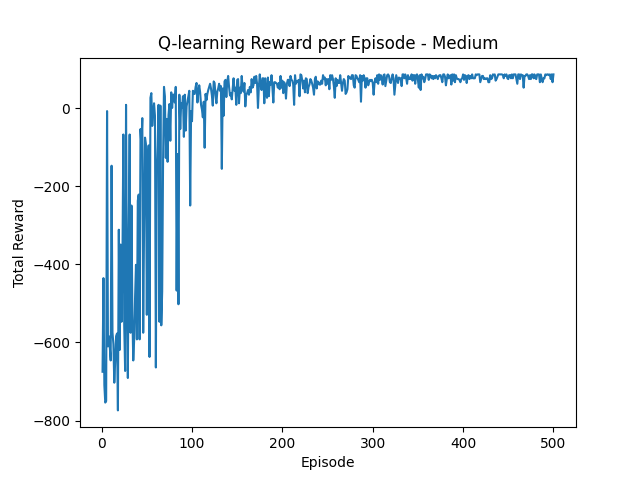

Q-learning_hard_rewards.png


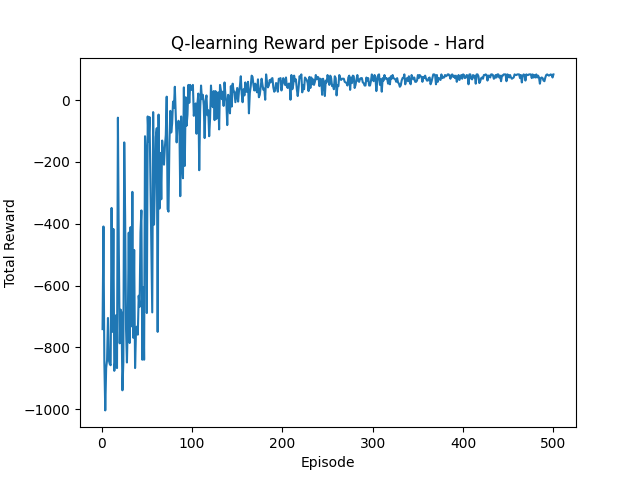

DQN_easy_rewards.png


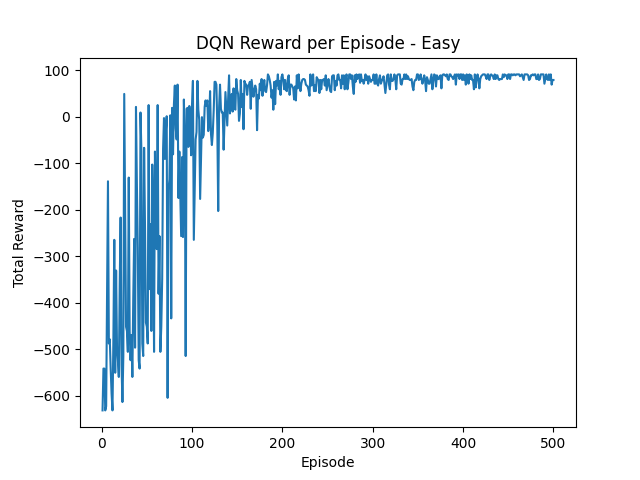

DQN_medium_rewards.png


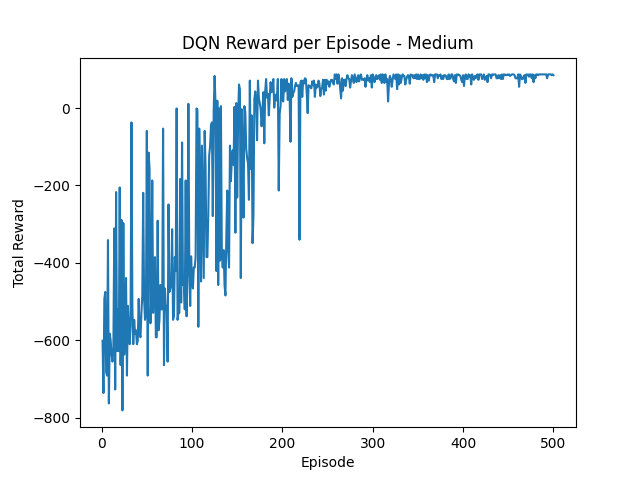

DQN_hard_rewards.png


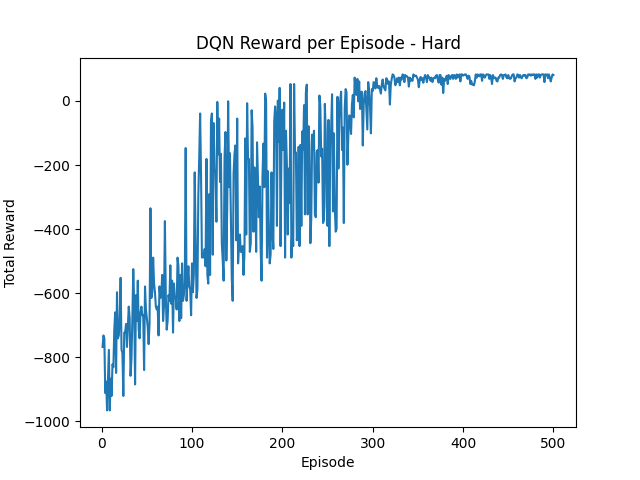

Missing: comparison_success_rate.png
Missing: comparison_avg_reward.png
Missing: comparison_avg_steps.png
Missing: comparison_training_time.png


In [21]:
from IPython.display import Image, display

graph_files = [
    "Q-learning_easy_rewards.png",
    "Q-learning_medium_rewards.png",
    "Q-learning_hard_rewards.png",
    "DQN_easy_rewards.png",
    "DQN_medium_rewards.png",
    "DQN_hard_rewards.png",
    "comparison_success_rate.png",
    "comparison_avg_reward.png",
    "comparison_avg_steps.png",
    "comparison_training_time.png",
]

for file_name in graph_files:
    path = os.path.join("results", file_name)
    if os.path.exists(path):
        print(file_name)
        display(Image(filename=path))
    else:
        print("Missing:", file_name)